In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Database

In [3]:
dataset = pd.read_csv(r"../data/dataset_projeto1.csv")
df = pd.DataFrame(dataset)
df

,x,y
0,0.000000,0.798686
1,0.033445,0.644703
2,0.066890,1.057624
3,0.100334,1.503789
4,0.133779,0.893427
...,...,...
295,9.866221,0.449840
296,9.899666,1.180636
297,9.933110,1.034273
298,9.966555,1.320299


In [4]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1:].values

print(f"({len(X)}, {len(y)})")

(300, 300)


In [5]:
df.isnull().sum()

x    0
y    0
dtype: int64

In [6]:
print(f"Máximos: X={max(X)}, y={max(y)}")
print(f"Mínimos: X={min(X)}, y={min(y)}")

Máximos: X=[10.], y=[2.65526553]
Mínimos: X=[0.], y=[-1.48885142]


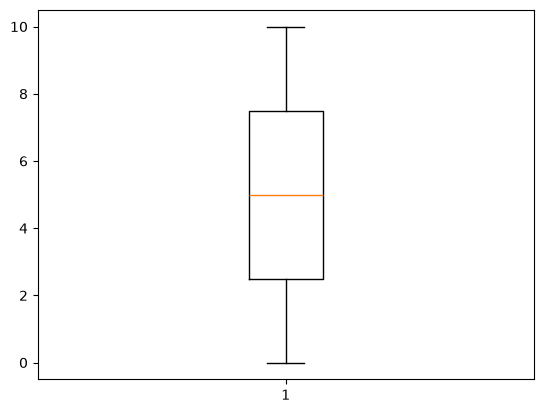

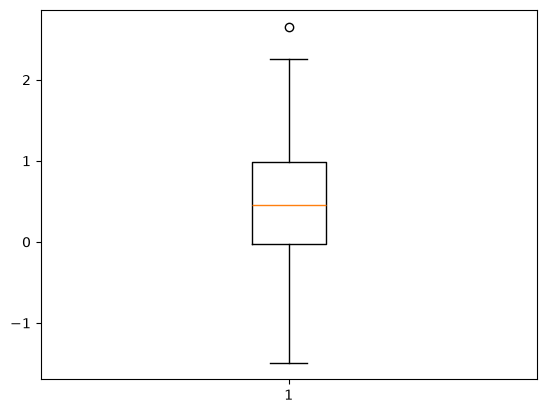

In [7]:
plt.boxplot(X)
plt.show()
plt.boxplot(y)
plt.show()

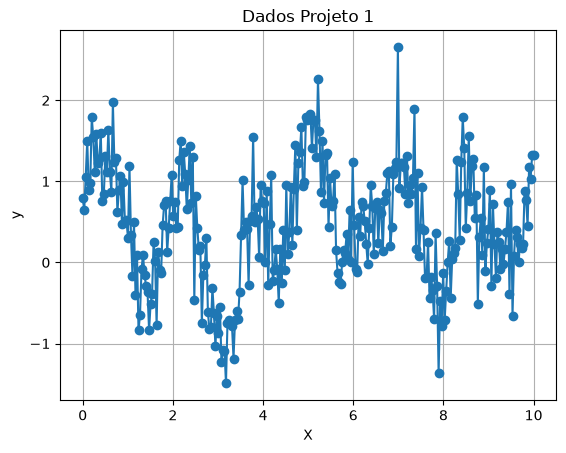

In [8]:
plt.plot(X, y, marker='o', linestyle='-')
plt.title("Dados Projeto 1")
plt.xlabel("X")
plt.ylabel("y")
plt.grid()
plt.show()

In [9]:
X_test, X_temp, y_test, y_temp = sklearn.model_selection.train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

print(f"(X_train, y_train) = ({len(X_train)}, {len(y_train)})")
print(f"(X_test, y_test) = ({len(X_test)}, {len(y_test)})")
print(f"(X_val, y_val) = ({len(X_val)}, {len(y_val)})")

(X_train, y_train) = (30, 30)
(X_test, y_test) = (240, 240)
(X_val, y_val) = (30, 30)


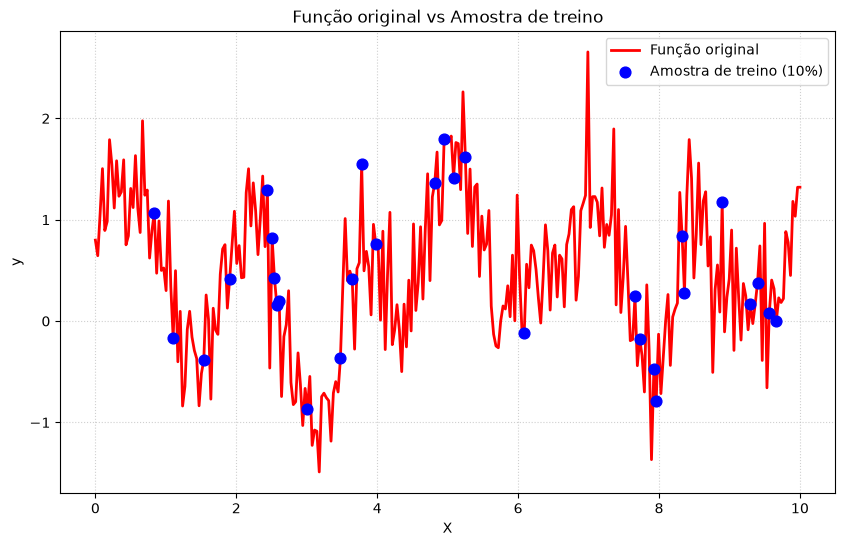

In [10]:
idx = np.argsort(X.ravel())

X_sorted = X.ravel()[idx]
y_sorted = y.ravel()[idx]

plt.figure(figsize=(10, 6))

plt.plot(
    X_sorted,
    y_sorted,
    label="Função original",
    linewidth=2,
    color="red"
)

plt.scatter(
    X_train.ravel(),
    y_train.ravel(),
    label="Amostra de treino (10%)",
    s=60,
    zorder=3,
    color="blue"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Função original vs Amostra de treino")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

## Data scalling

### Standard

In [11]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

X_train_standard = standard_scaler.fit_transform(X_train)
X_val_standard = standard_scaler.transform(X_val)
X_test_standard = standard_scaler.transform(X_test)

X_train_standard = torch.tensor(X_train_standard, dtype=torch.float32)
X_val_standard = torch.tensor(X_val_standard, dtype=torch.float32)
X_test_standard = torch.tensor(X_test_standard, dtype=torch.float32)

### MinMax

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)
X_val_minmax = scaler_minmax.transform(X_val)

X_train_minmax = torch.tensor(X_train_minmax, dtype=torch.float32)
X_val_minmax = torch.tensor(X_val_minmax, dtype=torch.float32)
X_test_minmax = torch.tensor(X_test_minmax, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# MLP

In [13]:
class MLPBaseline(nn.Module):
    def __init__(self, fc1_size, fc2_size, fc3_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1,fc1_size),
            nn.ReLU(),
            nn.Linear(fc1_size,fc2_size),
            nn.ReLU(),
            nn.Linear(fc2_size,fc3_size),
            nn.ReLU(),
            nn.Linear(fc3_size,1)
        )
        
    def forward(self, X):
        return self.layers(X)

In [14]:
def train(model, device, train_loader, X_val, y_val, criterion, optimizer, n_epochs=100):
    train_loss_hist = []
    val_loss_hist = []
    train_mae_hist = []
    val_mae_hist = []
    
    mae_criterion = nn.L1Loss()
    
    best_val_loss = float('inf')
    best_epoch = 0
    best_weights = None
    
    X_val = X_val.to(device)
    y_val = y_val.to(device)
    
    for epoch in range(n_epochs):
        model.train()
        
        batch_losses = []
        batch_maes = []
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            loss.backward()
            optimizer.step()
            
            batch_losses.append(loss.item())
            
            with torch.no_grad():
                mae = mae_criterion(y_pred, y_batch)
                batch_maes.append(mae.item())

        avg_train_loss = np.mean(batch_losses)
        avg_train_mae = np.mean(batch_maes)
        
        train_loss_hist.append(avg_train_loss)
        train_mae_hist.append(avg_train_mae)
        
        # Validação
        model.eval()
        
        with torch.no_grad():
            y_val_pred = model(X_val)
            
            val_loss = criterion(y_val_pred, y_val).item()
            val_mae = mae_criterion(y_val_pred, y_val).item()
        
        val_loss_hist.append(val_loss)
        val_mae_hist.append(val_mae)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_weights = copy.deepcopy(model.state_dict())
        
        if epoch == 0 or (epoch + 1) % 100 == 0 or (epoch + 1) == n_epochs:
            print(
                f"Epoch {epoch + 1}/{n_epochs} | "
                f"Train MSE: {avg_train_loss:.4f} | "
                f"Val MSE: {val_loss:.4f}"
            )
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    idx = best_epoch - 1
    best_metrics = {
        "epoch": best_epoch,
        
        "train_mse": train_loss_hist[idx],
        "train_rmse": np.sqrt(train_loss_hist[idx]),
        "train_mae": train_mae_hist[idx],
        
        "val_mse": val_loss_hist[idx],
        "val_rmse": np.sqrt(val_loss_hist[idx]),
        "val_mae": val_mae_hist[idx],
    }
    
    print("\n" + "=" * 50)
    print(" TRAINING SUMMARY")
    print("=" * 50)
    
    print(f" Best Epoch        : {best_metrics['epoch']}")
    
    print("-" * 50)
    
    print(f" Train MSE         : {best_metrics['train_mse']:.4f}")
    print(f" Train RMSE        : {best_metrics['train_rmse']:.4f}")
    print(f" Train MAE         : {best_metrics['train_mae']:.4f}")
    
    print("-" * 50)
    
    print(f" Val MSE           : {best_metrics['val_mse']:.4f}")
    print(f" Val RMSE          : {best_metrics['val_rmse']:.4f}")
    print(f" Val MAE           : {best_metrics['val_mae']:.4f}")
    
    print("=" * 50 + "\n")
    
    return (
        train_loss_hist,
        val_loss_hist,
        train_mae_hist,
        val_mae_hist,
        best_metrics
    )

In [15]:
def eval(model, X_test, y_test, criterion, device):
    model.eval()

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        y_pred = model(X_test)

        mse = criterion(y_pred, y_test).item()

        mae_criterion = nn.L1Loss()
        mae = mae_criterion(y_pred, y_test).item()

    rmse = np.sqrt(mse)

    return {
        "MSE": float(mse),
        "RMSE": float(rmse),
        "MAE": float(mae),
        "y_true": y_test.cpu().numpy().flatten(),
        "y_pred": y_pred.cpu().numpy().flatten()
    }

In [16]:
def plot_training_history(train_loss, val_loss, train_mae, val_mae, title="Treinamento"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # MSE
    ax1.plot(
        train_loss,
        label="Treino (Loss MSE)",
        linewidth=2
    )

    ax1.plot(
        val_loss,
        label="Validação (Loss MSE)",
        linewidth=2
    )

    ax1.set_title("Evolução da Loss (MSE)", fontsize=12)
    ax1.set_xlabel("Épocas")
    ax1.set_ylabel("Erro Quadrático Médio")
    ax1.legend()
    ax1.grid(True, linestyle=":", alpha=0.6)

    # MAE
    ax2.plot(
        train_mae,
        label="Treino (MAE)",
        linewidth=2
    )

    ax2.plot(
        val_mae,
        label="Validação (MAE)",
        linewidth=2
    )

    ax2.set_title("Evolução da Métrica Auxiliar (MAE)", fontsize=12)
    ax2.set_xlabel("Épocas")
    ax2.set_ylabel("Erro Absoluto Médio")
    ax2.legend()
    ax2.grid(True, linestyle=":", alpha=0.6)

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Treinamento dos Modelos

In [17]:
FC1_SIZE = 64
FC2_SIZE = 128
FC3_SIZE = 64
EPOCHS = 5000
BATCH_SIZE = 5

In [18]:
train_set_standard = TensorDataset(X_train_standard, y_train)
train_loader_standard = DataLoader(train_set_standard, batch_size=BATCH_SIZE, shuffle=True)

### Baseline

In [19]:
torch.manual_seed(42)

model_baseline = MLPBaseline(fc1_size=FC1_SIZE, fc2_size=FC2_SIZE, fc3_size=FC3_SIZE).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_baseline.parameters(), lr=0.01)
n_epochs = EPOCHS

train_loss_baseline, val_loss_baseline, train_mae_baseline, val_mae_baseline, metrics = train(
    model=model_baseline,
    device=device,
    train_loader=train_loader_standard,
    X_val=X_val_standard,
    y_val=y_val,
    criterion=loss_fn, 
    optimizer=optimizer,
    n_epochs=EPOCHS,
)

Epoch 1/5000 | Train MSE: 0.8031 | Val MSE: 0.8062
Epoch 100/5000 | Train MSE: 0.4041 | Val MSE: 0.6784
Epoch 200/5000 | Train MSE: 0.3393 | Val MSE: 0.6567
Epoch 300/5000 | Train MSE: 0.3209 | Val MSE: 0.6595
Epoch 400/5000 | Train MSE: 0.3033 | Val MSE: 0.6102
Epoch 500/5000 | Train MSE: 0.2810 | Val MSE: 0.5888
Epoch 600/5000 | Train MSE: 0.2810 | Val MSE: 0.5945
Epoch 700/5000 | Train MSE: 0.2740 | Val MSE: 0.6724
Epoch 800/5000 | Train MSE: 0.2560 | Val MSE: 0.6317
Epoch 900/5000 | Train MSE: 0.2384 | Val MSE: 0.7306
Epoch 1000/5000 | Train MSE: 0.2451 | Val MSE: 0.7457
Epoch 1100/5000 | Train MSE: 0.2529 | Val MSE: 0.6648
Epoch 1200/5000 | Train MSE: 0.2211 | Val MSE: 0.7735
Epoch 1300/5000 | Train MSE: 0.2167 | Val MSE: 0.6733
Epoch 1400/5000 | Train MSE: 0.2090 | Val MSE: 0.7361
Epoch 1500/5000 | Train MSE: 0.2366 | Val MSE: 0.7722
Epoch 1600/5000 | Train MSE: 0.1709 | Val MSE: 0.7239
Epoch 1700/5000 | Train MSE: 0.1656 | Val MSE: 0.7678
Epoch 1800/5000 | Train MSE: 0.1650 | Va

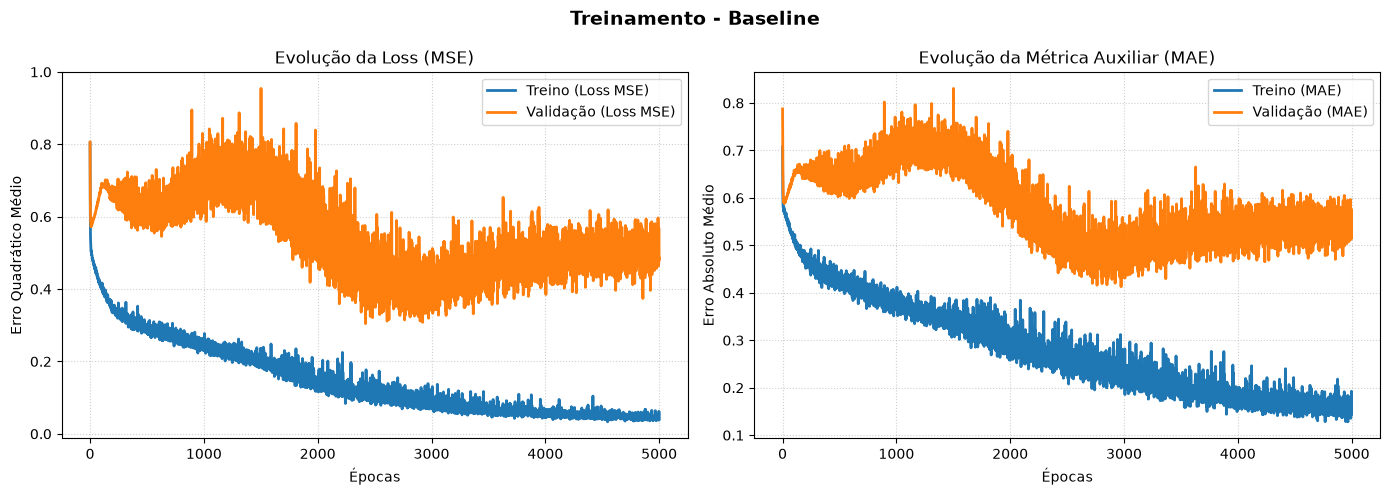

In [20]:
plot_training_history(
    train_loss_baseline,
    val_loss_baseline,
    train_mae_baseline,
    val_mae_baseline,
    title="Treinamento - Baseline"
)

### Momentum

$$\Delta w^t = \eta\delta + \alpha\Delta w^{t-1}$$

$$\Delta w^t = 0.01 \cdot \delta + 0.9 \cdot \Delta w^{t-1}$$

In [21]:
torch.manual_seed(42)
model_momentum = MLPBaseline(fc1_size=FC1_SIZE, fc2_size=FC2_SIZE, fc3_size=FC3_SIZE).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_momentum.parameters(), lr=0.01, momentum=0.9)

train_loss_momentum = []
val_loss_momentum = []

train_loss_momentum, val_loss_momentum, train_mae_momentum, val_mae_momentum, metrics = train(
    model=model_momentum,
    device=device,
    train_loader=train_loader_standard,
    X_val=X_val_standard,
    y_val=y_val,
    criterion=loss_fn, 
    optimizer=optimizer,
    n_epochs=EPOCHS,
)

Epoch 1/5000 | Train MSE: 0.7513 | Val MSE: 0.6038
Epoch 100/5000 | Train MSE: 0.2650 | Val MSE: 0.5603
Epoch 200/5000 | Train MSE: 0.2385 | Val MSE: 0.6356
Epoch 300/5000 | Train MSE: 0.1737 | Val MSE: 0.6374
Epoch 400/5000 | Train MSE: 0.2180 | Val MSE: 0.7396
Epoch 500/5000 | Train MSE: 0.1199 | Val MSE: 0.6003
Epoch 600/5000 | Train MSE: 0.1180 | Val MSE: 0.5031
Epoch 700/5000 | Train MSE: 0.0701 | Val MSE: 0.4127
Epoch 800/5000 | Train MSE: 0.1197 | Val MSE: 0.4526
Epoch 900/5000 | Train MSE: 0.0801 | Val MSE: 0.3962
Epoch 1000/5000 | Train MSE: 0.1434 | Val MSE: 0.4618
Epoch 1100/5000 | Train MSE: 0.1371 | Val MSE: 0.4061
Epoch 1200/5000 | Train MSE: 0.0797 | Val MSE: 0.3589
Epoch 1300/5000 | Train MSE: 0.1144 | Val MSE: 0.3627
Epoch 1400/5000 | Train MSE: 0.0967 | Val MSE: 0.4864
Epoch 1500/5000 | Train MSE: 0.1184 | Val MSE: 0.6183
Epoch 1600/5000 | Train MSE: 0.1182 | Val MSE: 0.4348
Epoch 1700/5000 | Train MSE: 0.0863 | Val MSE: 0.3953
Epoch 1800/5000 | Train MSE: 0.1259 | Va

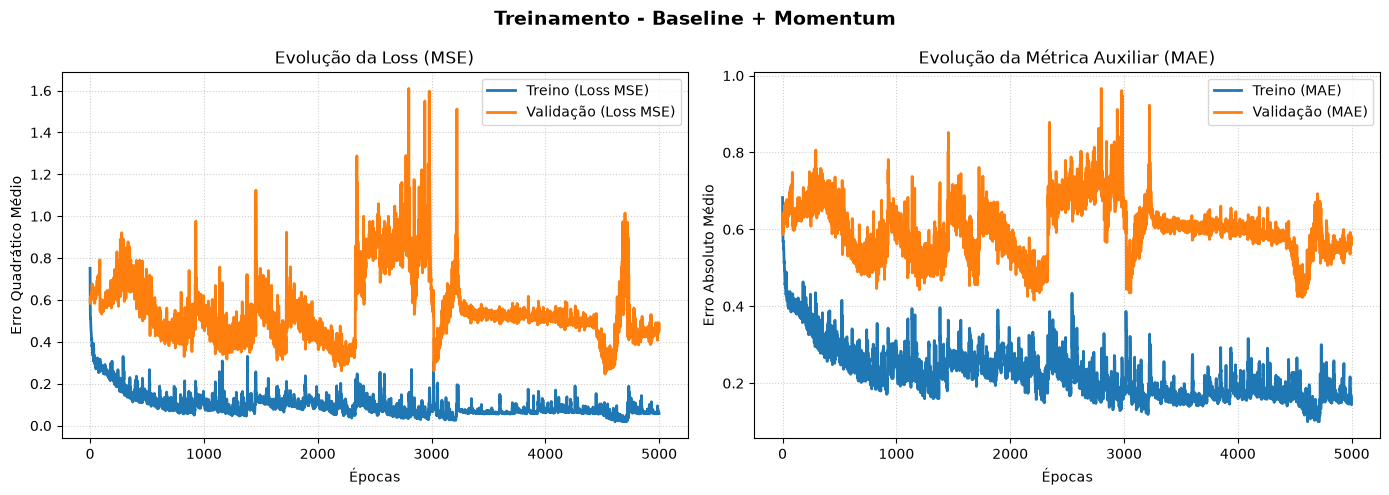

In [22]:
plot_training_history(
    train_loss_momentum,
    val_loss_momentum,
    train_mae_momentum,
    val_mae_momentum,
    title="Treinamento - Baseline + Momentum"
)

### Regularização

#### L2

$$E = E_0 + \frac{\lambda}{2n} \sum_w w^2$$

In [23]:
torch.manual_seed(42)
model_L2 = MLPBaseline(fc1_size=FC1_SIZE, fc2_size=FC2_SIZE, fc3_size=FC3_SIZE).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_L2.parameters(), lr=0.01, weight_decay=1e-6)

train_loss_L2 = []
val_loss_L2 = []

train_loss_L2, val_loss_L2, train_mae_L2, val_mae_L2, metrics = train(
    model=model_L2,
    device=device,
    train_loader=train_loader_standard,
    X_val=X_val_standard,
    y_val=y_val,
    criterion=loss_fn, 
    optimizer=optimizer,
    n_epochs=EPOCHS,
)

Epoch 1/5000 | Train MSE: 0.8031 | Val MSE: 0.8062
Epoch 100/5000 | Train MSE: 0.4041 | Val MSE: 0.6782
Epoch 200/5000 | Train MSE: 0.3393 | Val MSE: 0.6564
Epoch 300/5000 | Train MSE: 0.3210 | Val MSE: 0.6600
Epoch 400/5000 | Train MSE: 0.3031 | Val MSE: 0.6093
Epoch 500/5000 | Train MSE: 0.2814 | Val MSE: 0.5863
Epoch 600/5000 | Train MSE: 0.2806 | Val MSE: 0.5922
Epoch 700/5000 | Train MSE: 0.2744 | Val MSE: 0.6762
Epoch 800/5000 | Train MSE: 0.2542 | Val MSE: 0.6375
Epoch 900/5000 | Train MSE: 0.2371 | Val MSE: 0.7400
Epoch 1000/5000 | Train MSE: 0.2444 | Val MSE: 0.7527
Epoch 1100/5000 | Train MSE: 0.2514 | Val MSE: 0.6687
Epoch 1200/5000 | Train MSE: 0.2199 | Val MSE: 0.7913
Epoch 1300/5000 | Train MSE: 0.2164 | Val MSE: 0.6785
Epoch 1400/5000 | Train MSE: 0.2082 | Val MSE: 0.7449
Epoch 1500/5000 | Train MSE: 0.2367 | Val MSE: 0.7789
Epoch 1600/5000 | Train MSE: 0.1695 | Val MSE: 0.7279
Epoch 1700/5000 | Train MSE: 0.1631 | Val MSE: 0.7727
Epoch 1800/5000 | Train MSE: 0.1649 | Va

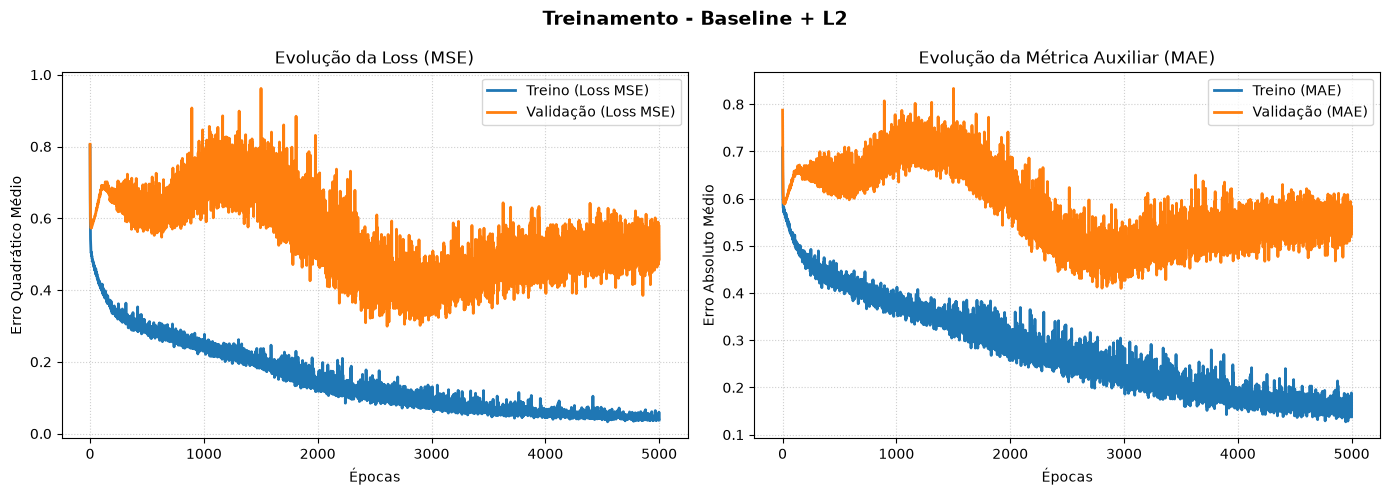

In [24]:
plot_training_history(
    train_loss_L2,
    val_loss_L2,
    train_mae_L2,
    val_mae_L2,
    title="Treinamento - Baseline + L2"
)

#### L1

$$E = E_0 + \lambda \sum \vert{}w\vert{}$$

In [25]:
def train_L1(model, device, train_loader, X_val, y_val, criterion, optimizer, regularization='', lambda_reg=0.01, n_epochs=100):
    train_loss_hist = []
    val_loss_hist = []
    train_mae_hist = []
    val_mae_hist = []
    
    mae_criterion = nn.L1Loss()
    
    best_val_loss = float('inf')
    best_epoch = 0
    best_weights = None
    
    X_val = X_val.to(device)
    y_val = y_val.to(device)
    
    for epoch in range(n_epochs):
        model.train()
        
        batch_losses = []
        batch_maes = []
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            
            y_pred = model(X_batch)
            mse_loss = criterion(y_pred, y_batch)
            loss = mse_loss
            
            if(regularization=='L1'):
                l1_norm = sum(param.abs().sum() for param in model.parameters())
                loss+=lambda_reg * l1_norm
                
            loss.backward()
            optimizer.step()
            
            batch_losses.append(mse_loss.item())
            
            with torch.no_grad():
                mae = mae_criterion(y_pred, y_batch)
                batch_maes.append(mae.item())

        avg_train_loss = np.mean(batch_losses)
        avg_train_mae = np.mean(batch_maes)
        
        train_loss_hist.append(avg_train_loss)
        train_mae_hist.append(avg_train_mae)
        
        # Validação
        model.eval()
        
        with torch.no_grad():
            y_val_pred = model(X_val)
            
            val_loss = criterion(y_val_pred, y_val).item()
            val_mae = mae_criterion(y_val_pred, y_val).item()
        
        val_loss_hist.append(val_loss)
        val_mae_hist.append(val_mae)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_weights = copy.deepcopy(model.state_dict())
        
        if epoch == 0 or (epoch + 1) % 100 == 0 or (epoch + 1) == n_epochs:
            print(
                f"Epoch {epoch + 1}/{n_epochs} | "
                f"Train MSE: {avg_train_loss:.4f} | "
                f"Val MSE: {val_loss:.4f}"
            )
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    idx = best_epoch - 1
    best_metrics = {
        "epoch": best_epoch,
        
        "train_mse": train_loss_hist[idx],
        "train_rmse": np.sqrt(train_loss_hist[idx]),
        "train_mae": train_mae_hist[idx],
        
        "val_mse": val_loss_hist[idx],
        "val_rmse": np.sqrt(val_loss_hist[idx]),
        "val_mae": val_mae_hist[idx],
    }
    
    print("\n" + "=" * 50)
    print(" TRAINING SUMMARY")
    print("=" * 50)
    
    print(f" Best Epoch        : {best_metrics['epoch']}")
    
    print("-" * 50)
    
    print(f" Train MSE         : {best_metrics['train_mse']:.4f}")
    print(f" Train RMSE        : {best_metrics['train_rmse']:.4f}")
    print(f" Train MAE         : {best_metrics['train_mae']:.4f}")
    
    print("-" * 50)
    
    print(f" Val MSE           : {best_metrics['val_mse']:.4f}")
    print(f" Val RMSE          : {best_metrics['val_rmse']:.4f}")
    print(f" Val MAE           : {best_metrics['val_mae']:.4f}")
    
    print("=" * 50 + "\n")
    
    return (
        train_loss_hist,
        val_loss_hist,
        train_mae_hist,
        val_mae_hist,
        best_metrics
    )

In [26]:
torch.manual_seed(42)
model_L1 = MLPBaseline(fc1_size=FC1_SIZE, fc2_size=FC2_SIZE, fc3_size=FC3_SIZE).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_L1.parameters(), lr=0.01)

train_loss_L1, val_loss_L1, train_mae_L1, val_mae_L1, metrics = train_L1(
    model=model_L1,
    device=device,
    train_loader=train_loader_standard,
    X_val=X_val_standard,
    y_val=y_val,
    criterion=loss_fn,
    lambda_reg=1e-5,
    optimizer=optimizer,
    regularization='L1',
    n_epochs=EPOCHS,
)

Epoch 1/5000 | Train MSE: 0.8127 | Val MSE: 0.8062
Epoch 100/5000 | Train MSE: 0.4138 | Val MSE: 0.6779
Epoch 200/5000 | Train MSE: 0.3490 | Val MSE: 0.6562
Epoch 300/5000 | Train MSE: 0.3308 | Val MSE: 0.6600
Epoch 400/5000 | Train MSE: 0.3129 | Val MSE: 0.6100
Epoch 500/5000 | Train MSE: 0.2910 | Val MSE: 0.5891
Epoch 600/5000 | Train MSE: 0.2910 | Val MSE: 0.5926
Epoch 700/5000 | Train MSE: 0.2842 | Val MSE: 0.6711
Epoch 800/5000 | Train MSE: 0.2662 | Val MSE: 0.6315
Epoch 900/5000 | Train MSE: 0.2477 | Val MSE: 0.7303
Epoch 1000/5000 | Train MSE: 0.2548 | Val MSE: 0.7477
Epoch 1100/5000 | Train MSE: 0.2635 | Val MSE: 0.6702
Epoch 1200/5000 | Train MSE: 0.2300 | Val MSE: 0.7769
Epoch 1300/5000 | Train MSE: 0.2277 | Val MSE: 0.6755
Epoch 1400/5000 | Train MSE: 0.2189 | Val MSE: 0.7455
Epoch 1500/5000 | Train MSE: 0.2471 | Val MSE: 0.7805
Epoch 1600/5000 | Train MSE: 0.1819 | Val MSE: 0.7270
Epoch 1700/5000 | Train MSE: 0.1728 | Val MSE: 0.7761
Epoch 1800/5000 | Train MSE: 0.1765 | Va

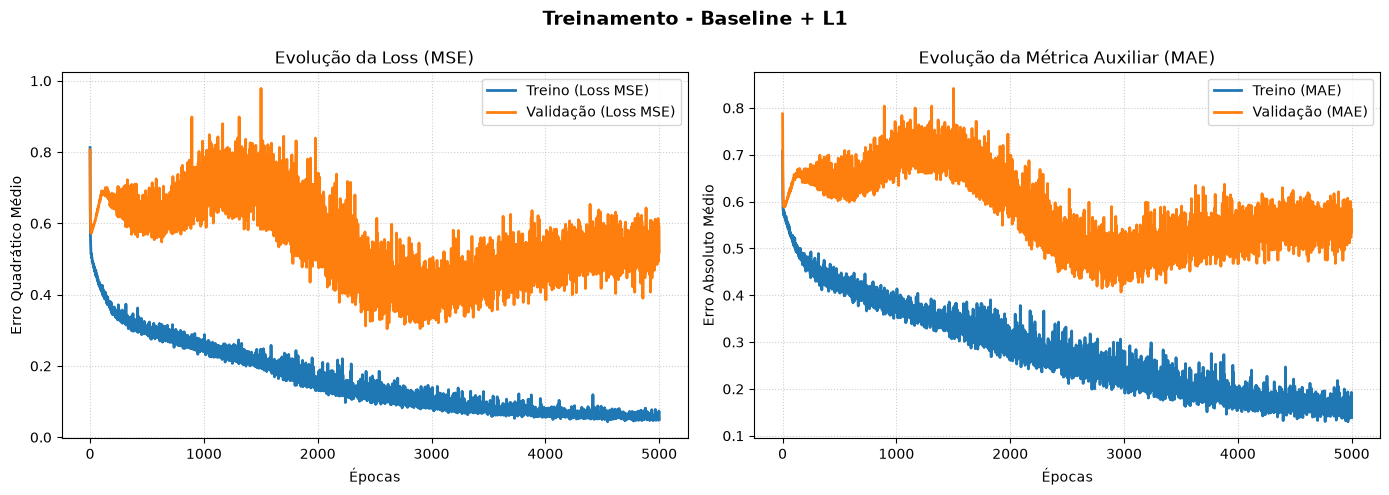

In [27]:
plot_training_history(
    train_loss_L1,
    val_loss_L1,
    train_mae_L1,
    val_mae_L1,
    title="Treinamento - Baseline + L1"
)

### Dropout

In [28]:
class MLPDropout(nn.Module):
    def __init__(self, fc1_size, fc2_size, fc3_size, p1=0.1, p2=0.1):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, fc1_size),
            nn.ReLU(),
            nn.Dropout(p1),
            nn.Linear(fc1_size, fc2_size),
            nn.ReLU(),
            nn.Dropout(p2),
            nn.Linear(fc2_size, fc3_size),
            nn.ReLU(),
            nn.Linear(fc3_size, 1)
        )
        
    def forward(self, X):
        return self.layers(X)

In [29]:
torch.manual_seed(42)

model_dropout = MLPDropout(fc1_size=FC1_SIZE, fc2_size=FC2_SIZE, fc3_size=FC3_SIZE, p1=0.05, p2=0.1).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_dropout.parameters(), lr=0.01)
n_epochs = EPOCHS
batch_size = 5

train_loss_dropout = []
val_loss_dropout = []

train_loss_dropout, val_loss_dropout, train_mae_dropout, val_mae_dropout, metrics = train(
    model=model_dropout,
    device=device, 
    train_loader=train_loader_standard,
    X_val=X_val_standard,
    y_val=y_val,
    criterion=loss_fn, 
    optimizer=optimizer,
    n_epochs=EPOCHS)

Epoch 1/5000 | Train MSE: 0.8071 | Val MSE: 0.8046
Epoch 100/5000 | Train MSE: 0.4047 | Val MSE: 0.6609
Epoch 200/5000 | Train MSE: 0.3540 | Val MSE: 0.6574
Epoch 300/5000 | Train MSE: 0.3263 | Val MSE: 0.6471
Epoch 400/5000 | Train MSE: 0.2864 | Val MSE: 0.6262
Epoch 500/5000 | Train MSE: 0.3069 | Val MSE: 0.6255
Epoch 600/5000 | Train MSE: 0.2566 | Val MSE: 0.6458
Epoch 700/5000 | Train MSE: 0.2950 | Val MSE: 0.6450
Epoch 800/5000 | Train MSE: 0.2832 | Val MSE: 0.6401
Epoch 900/5000 | Train MSE: 0.2447 | Val MSE: 0.6829
Epoch 1000/5000 | Train MSE: 0.2724 | Val MSE: 0.6869
Epoch 1100/5000 | Train MSE: 0.2691 | Val MSE: 0.6646
Epoch 1200/5000 | Train MSE: 0.2151 | Val MSE: 0.6876
Epoch 1300/5000 | Train MSE: 0.2294 | Val MSE: 0.6647
Epoch 1400/5000 | Train MSE: 0.2413 | Val MSE: 0.7174
Epoch 1500/5000 | Train MSE: 0.2409 | Val MSE: 0.7073
Epoch 1600/5000 | Train MSE: 0.2228 | Val MSE: 0.6949
Epoch 1700/5000 | Train MSE: 0.2055 | Val MSE: 0.6861
Epoch 1800/5000 | Train MSE: 0.1849 | Va

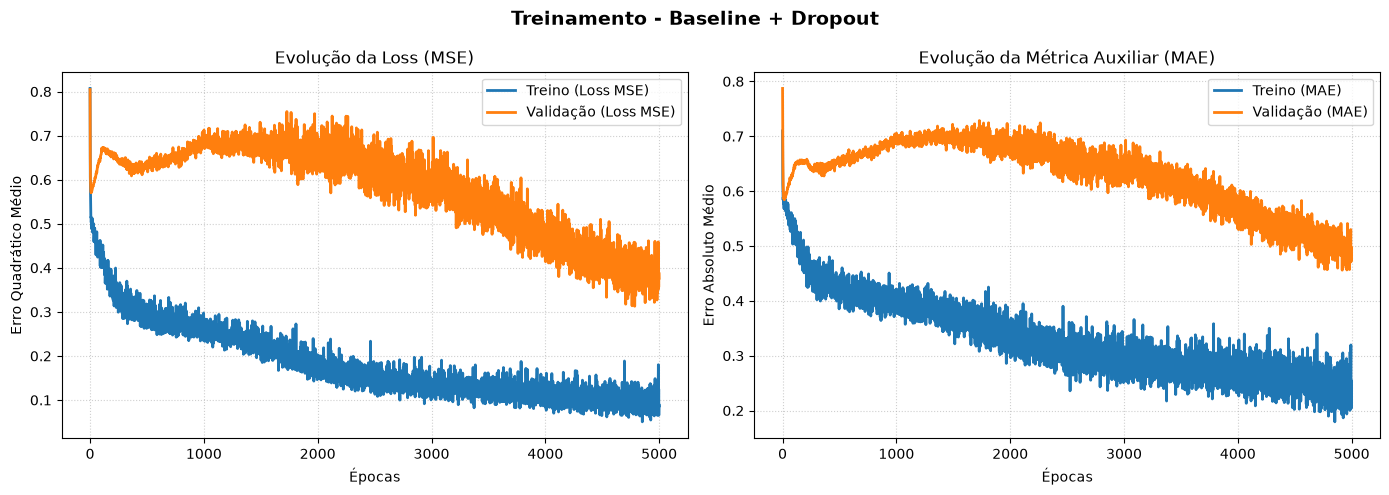

In [30]:
plot_training_history(
    train_loss_dropout,
    val_loss_dropout,
    train_mae_dropout,
    val_mae_dropout,
    title="Treinamento - Baseline + Dropout"
)

#### Combinando técnicas
* Momentum
* L2
* Dropout

In [31]:
torch.manual_seed(42)

model = MLPDropout(fc1_size=FC1_SIZE, fc2_size=FC2_SIZE, fc3_size=FC3_SIZE, p1=0.05, p2=0.1).to(device)
optimizer = optim.SGD(
    model.parameters(), 
    lr=0.01, 
    weight_decay=1e-6,
    momentum=0.9
)

criterion = nn.MSELoss()

train_loss, val_loss, train_mae, val_mae, metrics = train(
    model=model,
    device=device,
    train_loader=train_loader_standard,
    X_val=X_val_standard,
    y_val=y_val,
    criterion=criterion,
    optimizer=optimizer,
    n_epochs=5000
)

Epoch 1/5000 | Train MSE: 0.7537 | Val MSE: 0.5967
Epoch 100/5000 | Train MSE: 0.2626 | Val MSE: 0.5863
Epoch 200/5000 | Train MSE: 0.2368 | Val MSE: 0.5692
Epoch 300/5000 | Train MSE: 0.2084 | Val MSE: 0.5923
Epoch 400/5000 | Train MSE: 0.2021 | Val MSE: 0.6624
Epoch 500/5000 | Train MSE: 0.1649 | Val MSE: 0.7242
Epoch 600/5000 | Train MSE: 0.1682 | Val MSE: 0.6690
Epoch 700/5000 | Train MSE: 0.1790 | Val MSE: 0.5882
Epoch 800/5000 | Train MSE: 0.1415 | Val MSE: 0.5899
Epoch 900/5000 | Train MSE: 0.1397 | Val MSE: 0.6428
Epoch 1000/5000 | Train MSE: 0.1593 | Val MSE: 0.7023
Epoch 1100/5000 | Train MSE: 0.1330 | Val MSE: 0.6196
Epoch 1200/5000 | Train MSE: 0.1273 | Val MSE: 0.6419
Epoch 1300/5000 | Train MSE: 0.1488 | Val MSE: 0.6837
Epoch 1400/5000 | Train MSE: 0.1648 | Val MSE: 0.5117
Epoch 1500/5000 | Train MSE: 0.1328 | Val MSE: 0.5111
Epoch 1600/5000 | Train MSE: 0.1249 | Val MSE: 0.4771
Epoch 1700/5000 | Train MSE: 0.1252 | Val MSE: 0.5665
Epoch 1800/5000 | Train MSE: 0.1204 | Va

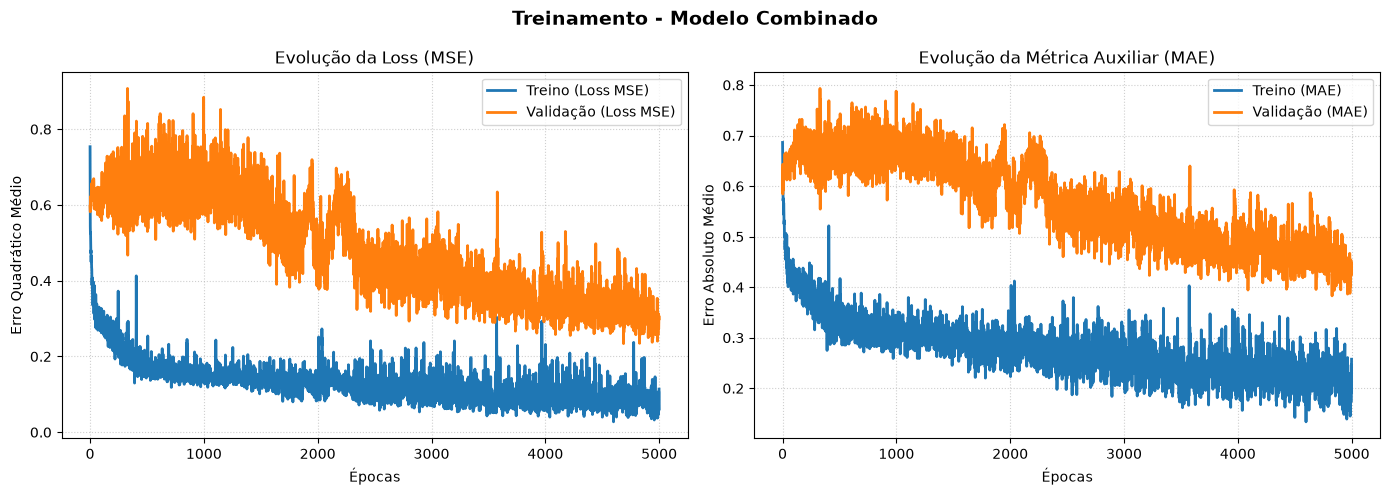

In [32]:
plot_training_history(
    train_loss,
    val_loss,
    train_mae,
    val_mae,
    title="Treinamento - Modelo Combinado"
)

## Resultados

In [33]:
results = {}

results["Baseline"] = eval(
    model_baseline,
    X_test_standard,
    y_test,
    nn.MSELoss(),
    device
)

results["Momentum"] = eval(
    model_momentum,
    X_test_standard,
    y_test,
    nn.MSELoss(),
    device
)

results["L1"] = eval(
    model_L1,
    X_test_standard,
    y_test,
    nn.MSELoss(),
    device
)

results["L2"] = eval(
    model_L2,
    X_test_standard,
    y_test,
    nn.MSELoss(),
    device
)

results["Dropout"] = eval(
    model_dropout,
    X_test_standard,
    y_test,
    nn.MSELoss(),
    device
)

results["Combinado"]  = eval(
    model,
    X_test_standard,
    y_test,
    nn.MSELoss(),
    device
) 

In [34]:
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    print(f"MSE  : {metrics['MSE']:.4f}")
    print(f"RMSE : {metrics['RMSE']:.4f}")
    print(f"MAE  : {metrics['MAE']:.4f}")


Baseline
MSE  : 0.5183
RMSE : 0.7199
MAE  : 0.5650

Momentum
MSE  : 0.3809
RMSE : 0.6172
MAE  : 0.4880

L1
MSE  : 0.5316
RMSE : 0.7291
MAE  : 0.5715

L2
MSE  : 0.5295
RMSE : 0.7277
MAE  : 0.5691

Dropout
MSE  : 0.4623
RMSE : 0.6799
MAE  : 0.5280

Combinado
MSE  : 0.4053
RMSE : 0.6366
MAE  : 0.5025


In [35]:
from sklearn.metrics import PredictionErrorDisplay
import os

def plot_parity_and_residuals(y_true, y_pred, title="Avaliação", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # gráfico de Paridade
    PredictionErrorDisplay.from_predictions(
        y_true=y_true, 
        y_pred=y_pred, 
        kind="actual_vs_predicted", 
        ax=ax1,
        scatter_kwargs={"alpha": 0.7, "edgecolors": "k"}
    )
    ax1.set_title("Gráfico de Paridade")

    # gráfico de Resíduos
    PredictionErrorDisplay.from_predictions(
        y_true=y_true, 
        y_pred=y_pred, 
        kind="residual_vs_predicted", 
        ax=ax2,
        scatter_kwargs={"alpha": 0.7, "edgecolors": "k"}
    )
    ax2.set_title("Gráfico de Resíduos")

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()

    plt.close(fig)

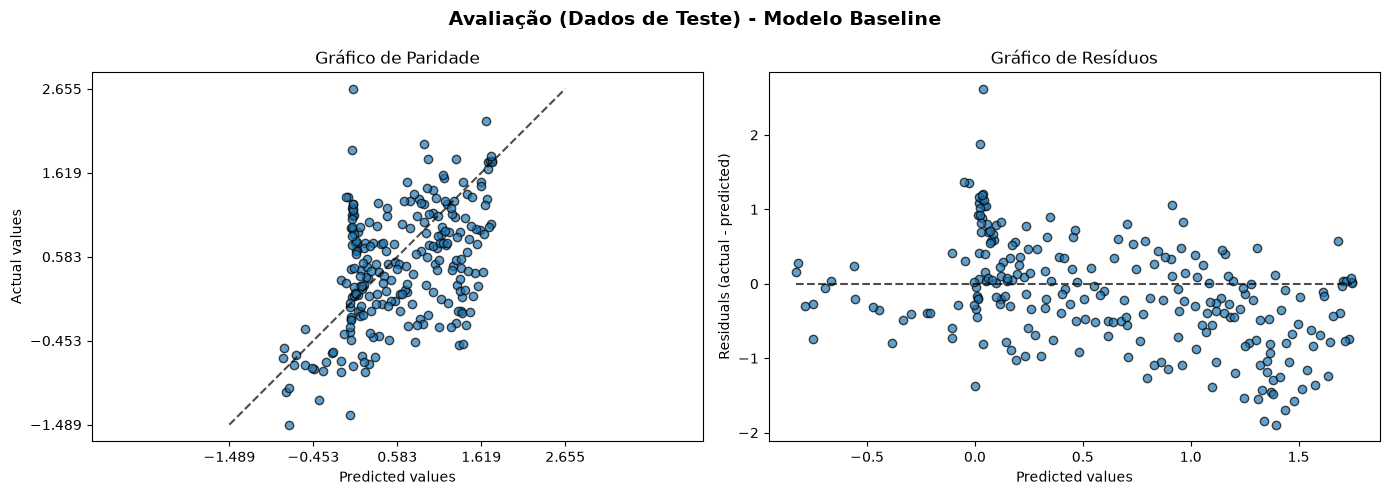

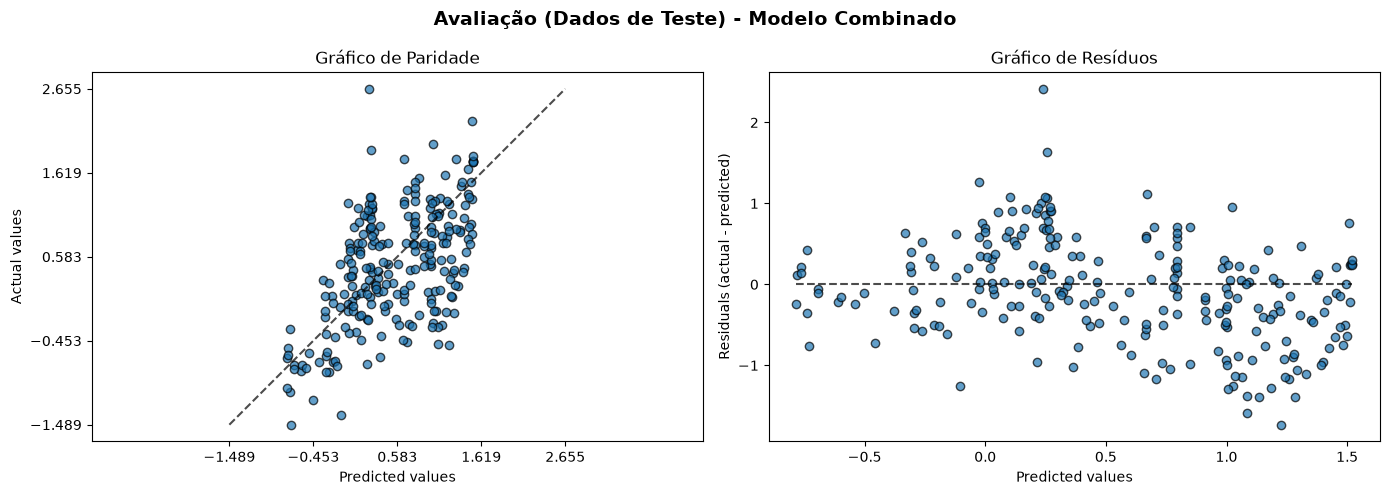

In [36]:
plot_parity_and_residuals(
    y_true=results["Baseline"]["y_true"], 
    y_pred=results["Baseline"]["y_pred"], 
    title="Avaliação (Dados de Teste) - Modelo Baseline"
)

plot_parity_and_residuals(
    y_true=results["Combinado"]["y_true"], 
    y_pred=results["Combinado"]["y_pred"], 
    title="Avaliação (Dados de Teste) - Modelo Combinado"
)